In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn.objects as so
import os
import sys
import scipy
import pandas
import math
import torch

notebook_dir = os.getcwd()
project_root_dir = os.path.dirname(notebook_dir) # This should resolve to /path/to/project_root/
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

import h5py
import numpy as np
from dataset import load_dataset
from config import DatasetConfig

In [ ]:
dataset = load_dataset(DatasetConfig(db_file="../dataset/fast-small-03.db", label="fast_nuclear_W_batch"))

In [61]:
dataset.trainX.shape[0]

180937

In [85]:
tensor= dataset.trainX.reshape((-1, 2))
mask = (tensor == torch.tensor([0, 0])).all(dim=1)
X = tensor[~mask]
Y = dataset.trainY.reshape((-1, 2))[~mask]
mask2 = (Y[:,0] > 1) | (Y[:,1] > 1) | (Y[:,0] < -1) | (Y[:,1] < -1)
X = X[~mask2]
Y = Y[~mask2]
torch.sum(mask2)

tensor(6816)

In [86]:
total_rows = X.shape[0]
proportion = 0.5 # 20%
sample_count = math.ceil(total_rows * proportion)
train_count = math.ceil(sample_count * 0.8)

random_indices = np.random.choice(total_rows, sample_count, replace=False)

random_indices_train = random_indices[0:train_count]
random_indices_validate = random_indices[train_count:]


In [87]:
X.shape, tensor.shape

(torch.Size([1635770, 2]), torch.Size([370558976, 2]))

In [ ]:
label ="fast_nuclear_W_batch"
with h5py.File("../dataset/fast-small-03-sampled.db", 'w') as f:
    grp = f.create_group(label+"_train")
    grp.create_dataset('input', data=X[random_indices_train], dtype=np.float32)
    grp.create_dataset('output', data=Y[random_indices_train], dtype=np.float32)

    grp = f.create_group(label+"_validate")
    grp.create_dataset('input', data=X[random_indices_validate], dtype=np.float32)
    grp.create_dataset('output', data=Y[random_indices_validate], dtype=np.float32)

In [90]:
# Representative Data
datasetX = dataset.trainX.numpy()
datasetY = dataset.trainY.numpy()
# Position
x0 = datasetX[:,0]
x1 = datasetX[:,1]

y0 = datasetY[:,0]
y1 = datasetY[:,1]


In [81]:
np.sum(y1 > 1)

np.int64(0)

In [91]:
# Baseline error with smoothl1 loss
import torch.nn as nn
import torch
l = datasetY.shape[0]
print("SmoothL1", nn.functional.smooth_l1_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)
print("L1", nn.functional.l1_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)
print("L2", nn.functional.mse_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)

SmoothL1 0.0001908715327844633
L1 0.016054555539356533
L2 0.0003817430655689266


/tmp/ipykernel_127186/955144348.py:5: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([654308, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print("SmoothL1", nn.functional.smooth_l1_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)
/tmp/ipykernel_127186/955144348.py:6: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([654308, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print("L1", nn.functional.l1_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)
/tmp/ipykernel_127186/955144348.py:7: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([654308, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print("L2",

In [92]:
data = [
    {"name": "x0", "value":x0},
    {"name": "x1", "value":x1},
    {"name": "y0", "value":y0, "log":True},
    {"name":  "y1", "value":y1, "log":True}
]


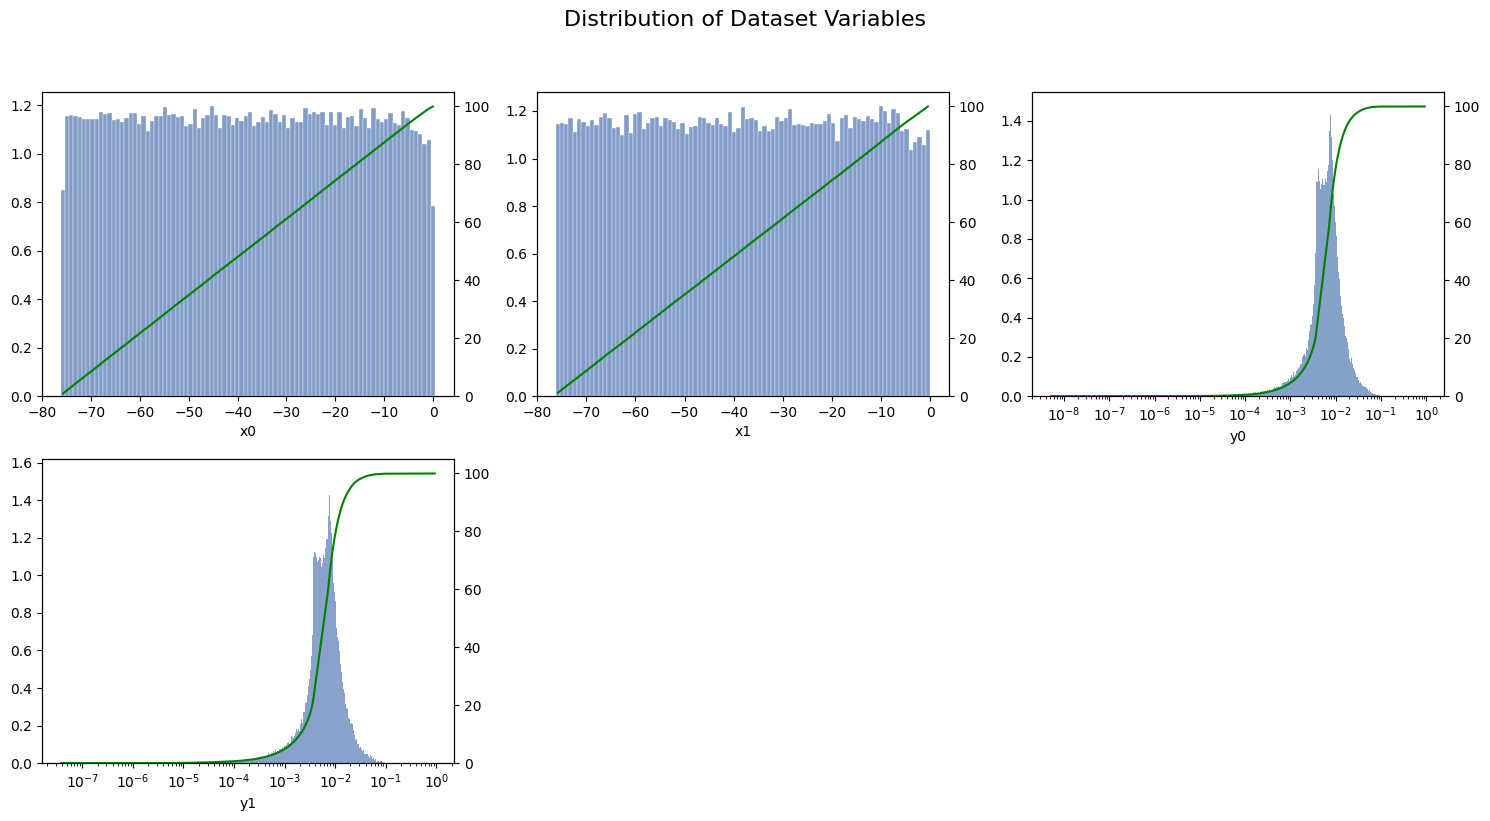

In [94]:
num_variables = len(data)
num_cols = 3
num_rows = math.ceil(num_variables / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), squeeze=False)
axes_flat = axes.flatten() # Flatten the 2D array of axes for easy iteration

# --- 5. Iterate Through Variables and Plot on Subplots ---
def plot(i, var_name, values, bins="auto", log=False):
    ax = axes_flat[i]

    plot_instance1 = (
        so.Plot(x=np.abs(values) if log else values)
        .on(ax) # Attach this plot to ax1
        .add(so.Bars(), so.Hist(bins=bins, stat='percent'))
    )

    ax2 = ax.twinx()
    plot_instance2 = (
        so.Plot(x=np.abs(values) if log else values)
        .on(ax2) # Attach this plot to ax1
        .add(so.Line(color='green'), so.Hist(bins=bins, stat='percent', cumulative=True))
        .limit(y=(0, None))
    )

    if log:
        plot_instance1 = plot_instance1.scale(x='log')
        plot_instance2 = plot_instance2.scale(x='log')

    plot_instance1.plot()
    plot_instance2.plot()

    ax2.yaxis.tick_right()
    ax.set_xlabel(var_name)

for (i, d) in enumerate(data):
    plot(i, d["name"], d["value"], log=d.get("log"), bins=d.get("bins") or "auto")
for j in range(num_variables, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.tight_layout()
fig.suptitle("Distribution of Dataset Variables", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
plt.savefig("distribution.svg")

In [93]:
print(f"Variable                  =     Mean (+/-  Std. Dev) [    Minimum,       Maximum]")
print("-" * 81)
for d in data:
    v = d["value"]
    print(f"{d["name"]:25} = {np.mean(v):+.5f} (+/- {np.std(v):9.6f}) [{np.min(v):12.6f}, {np.max(v):12.6f}]")

print(f"Total Datapoints: {data[0]['value'].size}")

Variable                  =     Mean (+/-  Std. Dev) [    Minimum,       Maximum]
---------------------------------------------------------------------------------
x0                        = -38.06779 (+/- 21.935960) [  -76.236191,     0.459997]
x1                        = -38.19788 (+/- 21.953954) [  -76.249992,    -0.000013]
y0                        = -0.00791 (+/-  0.010371) [   -0.913780,     0.942190]
y1                        = -0.00802 (+/-  0.012137) [   -0.949430,     0.652890]
Total Datapoints: 654308
